# qiu_2026 — in-silico analyses

Probes a trained `qiu_2026` digital twin with *synthetic* stimuli, rather than scoring it against
recordings (that is `qiu_2026_inspect_predictions.ipynb`).

Two analyses, chosen because the qiu model has two distinct behavioral pathways:

1. **MEIs per bouton.** Most-exciting-input optimization for individual axonal boutons, repeated at
   several behavioral states.
2. **Behavior-state modulation.** Sweeps of the behavior input channels (pupil size, locomotion) and
   of the pupil shifter's eye position.

**Why both.** The behavior channels are broadcast constant over height and width
(`data_io/qiu_2026/stimuli.py`), so they reach the core only through the first convolution's
input-channel weights — a constant per-output-channel offset ahead of BatchNorm and ELU. A
state-dependent bias before a nonlinearity is the *only* mechanism this architecture has for
behavioral gain: it can rescale or threshold a response, but it cannot reshape a receptive field.
The pupil-position shifter is the one pathway that can actually *move* a receptive field. Running
both separates gain from displacement.

**How to use.** Set `SESSION` / `CKPT_PATH` in the config cell (defaults auto-pick the newest
checkpoint), then run all cells.

In [1]:
# Inline backend, so figures are captured as cell outputs when this notebook is executed
# headlessly (nbconvert on the cluster). Without it a non-interactive backend silently
# swallows every plot.
%matplotlib inline

import json
import os
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir

from openretina.utils.file_utils import get_cache_directory
from openretina.models.core_readout import load_core_readout_model

# ---- config: edit these ----
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SESSION = None      # None -> the model's first readout head
CKPT_PATH = None    # None -> auto-pick the newest checkpoint under the latest run
N_BOUTONS = 24      # boutons to compute MEIs for (17.3k in total; pick a handful)
MEI_TIME_STEPS = 50
# ----------------------------

os.environ.setdefault("OPENRETINA_CACHE_DIRECTORY", str(get_cache_directory()))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("repo: ", REPO)
print("device:", device, "| cache:", os.environ["OPENRETINA_CACHE_DIRECTORY"])
assert (REPO / "configs" / "qiu_2026_core_readout.yaml").exists(), f"REPO looks wrong: {REPO}"

repo:  /mnt/lustre/work/bethge/bkr578/projects/open-retina
device: cuda | cache: /mnt/lustre/work/bethge/bkr578/openretina_cache


In [2]:
# Locate the checkpoint (newest .ckpt across all runs, unless CKPT_PATH is set)
if CKPT_PATH is None:
    ckpts = sorted(
        (REPO / "openretina_assets/runs/core_readout_qiu_2026_mouse").glob("*/checkpoints/*.ckpt"),
        key=lambda p: p.stat().st_mtime,
    )
    assert ckpts, "No checkpoint found yet - wait for the training job to finish epoch 0."
    CKPT_PATH = ckpts[-1]
CKPT_PATH = Path(CKPT_PATH)
print("Using checkpoint:", CKPT_PATH.name)

Using checkpoint: epoch=49_val_evaluation_loss=0.401_final.ckpt


In [3]:
model = load_core_readout_model(str(CKPT_PATH), device)
model.eval()  # deterministic Gaussian readout; the sweep helpers refuse a training-mode model

readout_sessions = list(model.readout.keys())
if SESSION is None:
    SESSION = readout_sessions[0]
assert SESSION in readout_sessions, f"{SESSION!r} not among {readout_sessions}"
assert getattr(model, "shifter", None) is not None, "This notebook assumes a shifter-equipped model."

n_boutons = model.readout[SESSION].outdims
print(f"{len(readout_sessions)} sessions | shifter: yes | {SESSION[:28]}... has {n_boutons} boutons")
print("input shape (c, h, w):", model.data_info["input_shape"])

10 sessions | shifter: yes | dynamic28188-16-3-Fluorescen... has 2710 boutons
input shape (c, h, w): (3, 36, 64)


### Where results are written

Every intermediate result is written to disk as it is produced, not at the end, so a failure late in
the notebook cannot cost you the expensive MEI optimizations. Arrays go to `.npz` (plain arrays, no
pickle) and run parameters to `metadata.json`, which is rewritten after each step so it stays valid
even if the notebook stops early.

The last section reloads all of it and re-plots from the files alone, proving the saved data is
sufficient to explore these results interactively in a fresh kernel with no GPU and no model.

**A note on reproducibility.** Quantities that are pure forward passes -- validation correlations,
and any sweep run on a *fixed* probe such as the grey stimulus -- come out bit-identical when this
notebook is re-run on different GPUs. Quantities computed *from an MEI* do not: cuDNN selects
different kernels per device, and the difference compounds over the optimization trajectory. Between
an RTX 2080 Ti and a V100 the MEI-probe modulation index moved 0.257 -> 0.274 and the quiet-state
structural similarity 0.911 -> 0.914, while the grey-probe index stayed at 0.280 to three decimals.
The conclusions are unaffected, but do not read the third decimal of an MEI-derived number as stable
across machines -- reload the saved `meis.npz` instead of re-optimizing if you need the exact ones
these figures were made from.


In [4]:
# openretina_assets/ is gitignored, so these files never bloat the repo.
RESULTS_DIR = REPO / "openretina_assets/insilico/qiu_2026" / SESSION
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
_metadata: dict = {}


def save_arrays(name: str, **arrays) -> Path:
    """Write named arrays to RESULTS_DIR/<name>.npz."""
    path = RESULTS_DIR / f"{name}.npz"
    np.savez_compressed(path, **arrays)
    print(f"  saved {path.name:26s} {path.stat().st_size / 1e6:7.2f} MB")
    return path


def record_metadata(**entries) -> None:
    """Merge entries into metadata.json, rewriting it each time so it is never left half-written."""
    _metadata.update(entries)
    (RESULTS_DIR / "metadata.json").write_text(json.dumps(_metadata, indent=2, default=str))


record_metadata(
    checkpoint=str(CKPT_PATH),
    session=SESSION,
    sessions=readout_sessions,
    device=device,
    n_boutons_session=int(n_boutons),
    input_shape=list(model.data_info["input_shape"]),
)
print("results ->", RESULTS_DIR)

results -> /mnt/lustre/work/bethge/bkr578/projects/open-retina/openretina_assets/insilico/qiu_2026/dynamic28188-16-3-Fluorescence-7b721b-v4a


## Setup: channel freezing, stimulus constraints, and a fixed eye position

Three decisions that everything below depends on.

**The behavior channels must not be optimized.** They are inputs, but they are not pixels — an
unconstrained MEI would happily "paint" locomotion. `FixedChannelStimulusModel` exposes the
3-channel model as a 1-channel (video-only) model and splices the constants back in on every
forward pass, so the optimizer only ever sees the video.

This is not merely tidier than freezing channels after each step. `ChangeNormJointlyClipRangeSeparately`
normalizes over *all* channels jointly, so renormalizing a 3-channel tensor and then restoring the
behavior constants shrinks the video by the same factor every iteration — it decays geometrically to
zero. `tests/insilico/stimulus_optimization/test_fixed_channel_model.py` pins that behavior down so
nobody rediscovers it by watching an MEI fade out.

**The range and norm are measured, not guessed.** `STIMULUS_RANGE_CONSTRAINTS` comes from the 0.1/99.9
percentiles of the z-scored video over all 10 sessions (2.3 × 10⁹ pixels). Note the asymmetry —
`[-1.29, +2.96]` — the raw movie's mean sits well below mid-grey, so clipping symmetrically would be
wrong. The norm is *derived* from the stimulus size rather than tabulated, because MEI length is a
free choice and a norm fixed for one length is silently wrong for another.

**Eye position is pinned at the session mean.** The pupil trace is z-scored per session, so
`(0, 0)` is that session's mean eye position. It has to be the *same* value for MEI optimization and
for the behavior sweep, or the MEI is optimized at one receptive-field location and probed at
another. Passing `pupil_center=None` instead would pin the readout at the bare `mu`, which equals
the mean position only if the shifter happens to map the mean pupil to zero — not something to
assume.

In [5]:
from openretina.data_io.qiu_2026.constants import (
    BEHAVIOR_SWEEP_RANGE,
    FRAME_RATE_MODEL,
    STIMULUS_RANGE_CONSTRAINTS,
    video_range_and_norm,
)
from openretina.insilico import FixedChannelStimulusModel

BEHAVIOR_CHANNELS = (1, 2)   # 0 = video, 1 = pupil size, 2 = locomotion
PUPIL_CENTER = (0.0, 0.0)    # session-mean eye position (the traces are z-scored)

min_max_values, mei_norm = video_range_and_norm(MEI_TIME_STEPS)
print("measured range/RMS:", STIMULUS_RANGE_CONSTRAINTS)
print(f"video range {min_max_values[0]} | derived norm at {MEI_TIME_STEPS} frames = {mei_norm:.1f}")
print("behavior sweep range:", BEHAVIOR_SWEEP_RANGE, "| frame rate:", FRAME_RATE_MODEL, "Hz")

measured range/RMS: {'x_min_video': -1.29, 'x_max_video': 2.96, 'rms_video': 0.996}
video range (-1.29, 2.96) | derived norm at 50 frames = 338.1
behavior sweep range: (-2.0, 2.0) | frame rate: 30 Hz


## Which boutons?

17,300 boutons is far too many to optimize. Rank by how well the model predicts each one on held-out
data and take the top `N_BOUTONS`: an MEI for a bouton the model cannot predict is an artifact of
the fit, not a statement about the cell.

In [6]:
# Build validation dataloaders for this one session (all 10 would exceed the kernel's memory).
with initialize_config_dir(config_dir=str(REPO / "configs"), version_base="1.3"):
    cfg = compose(
        config_name="qiu_2026_core_readout",
        overrides=[
            f"+data_io.stimuli.sessions=[{SESSION}]",
            f"+data_io.responses.sessions=[{SESSION}]",
            f"+data_io.pupil.sessions=[{SESSION}]",
            "dataloader.batch_size=8",
        ],
    )

movies = hydra.utils.call(cfg.data_io.stimuli)
responses = hydra.utils.call(cfg.data_io.responses)
pupil = hydra.utils.call(cfg.data_io.pupil)

# Grab the behaviour traces BEFORE building the dataloaders. `configs/dataloader/qiu_2026.yaml`
# sets `release_movies: true`, which destructively drops each session's entry from `movies` as the
# loader consumes it -- that is the ~28 GB saving, and it means `movies[SESSION]` is gone afterwards.
# The traces are broadcast over pixels, so one pixel carries the whole (2, t) signal for free.
behavior_trace = movies[SESSION].train[list(BEHAVIOR_CHANNELS), :, 0, 0].copy()
print("behavior traces kept for the density overlay:", behavior_trace.shape)

# `_partial_` on purpose: data passed *through* `instantiate` is OmegaConf-rebuilt, so the builder
# would receive copies and `release_movies` could not free the caller's movies (~28 GB). See
# hydra_partial_instantiate.md.
build_dataloaders = hydra.utils.instantiate(cfg.dataloader, _partial_=True)
dataloaders = build_dataloaders(
    neuron_data_dictionary=responses,
    movies_dictionary=movies,
    pupil_dictionary=pupil,
)
print("splits:", [k for k in dataloaders if k in ("train", "validation")], f"+ {len(dataloaders) - 2} test conditions")

save_arrays("behavior_trace", behavior_trace=behavior_trace)

qiu_2026 stimuli:   0%|          | 0/1 [00:00<?, ?it/s]

qiu_2026 responses:   0%|          | 0/1 [00:00<?, ?it/s]

qiu_2026 pupil:   0%|          | 0/1 [00:00<?, ?it/s]

behavior traces kept for the density overlay: (2, 38400)


Creating qiu movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

splits: ['train', 'validation'] + 95 test conditions
  saved behavior_trace.npz            0.18 MB


PosixPath('/mnt/lustre/work/bethge/bkr578/projects/open-retina/openretina_assets/insilico/qiu_2026/dynamic28188-16-3-Fluorescence-7b721b-v4a/behavior_trace.npz')

In [7]:
# Per-bouton validation correlation, with the shifter active (as in training).
def per_neuron_corr(a, b, eps=1e-8):
    a = a - a.mean(0, keepdims=True)
    b = b - b.mean(0, keepdims=True)
    return (a * b).mean(0) / (a.std(0) * b.std(0) + eps)


preds, targs = [], []
with torch.no_grad():
    for batch in dataloaders["validation"][SESSION]:
        out = model.forward(
            batch.inputs.to(device), data_key=SESSION, pupil_center=batch.pupil_center.to(device)
        )
        lag = batch.targets.shape[1] - out.shape[1]   # frames the causal core cannot predict
        preds.append(out.cpu().numpy().reshape(-1, out.shape[-1]))
        targs.append(batch.targets[:, lag:, :].numpy().reshape(-1, batch.targets.shape[-1]))

val_corr = per_neuron_corr(np.concatenate(preds), np.concatenate(targs))
top_boutons = np.argsort(np.nan_to_num(val_corr, nan=-np.inf))[::-1][:N_BOUTONS].tolist()

print(f"validation correlation: mean={np.nanmean(val_corr):.3f} median={np.nanmedian(val_corr):.3f}")
print(f"top {N_BOUTONS} boutons:", [(int(i), round(float(val_corr[i]), 3)) for i in top_boutons])

save_arrays("boutons", val_corr=val_corr, top_boutons=np.asarray(top_boutons))
record_metadata(
    val_corr_mean=float(np.nanmean(val_corr)),
    val_corr_median=float(np.nanmedian(val_corr)),
    n_top_boutons=len(top_boutons),
)

validation correlation: mean=0.560 median=0.554
top 24 boutons: [(1902, 0.863), (2364, 0.861), (2683, 0.853), (843, 0.85), (1653, 0.837), (955, 0.834), (556, 0.833), (1131, 0.818), (2668, 0.817), (1941, 0.816), (2625, 0.816), (2585, 0.815), (2648, 0.814), (1681, 0.812), (1114, 0.811), (945, 0.811), (584, 0.809), (1343, 0.809), (1019, 0.809), (2698, 0.807), (591, 0.807), (795, 0.806), (333, 0.805), (1329, 0.804)]
  saved boutons.npz                   0.01 MB


## 1. MEIs per bouton, at three behavioral states

One MEI per bouton per state. If the behavior channels only apply a gain, the three MEIs for a
bouton should differ in *amplitude* but keep the same spatiotemporal structure — that is the
prediction the architecture makes, and it is worth checking rather than assuming.

In [8]:
from functools import partial

from openretina.insilico import IncreaseObjective, OptimizationStopper, SliceMeanReducer, optimize_stimulus
from openretina.insilico.stimulus_optimization.regularizer import (
    ChangeNormJointlyClipRangeSeparately,
    RangeRegularizationLoss,
)

# (pupil size, locomotion) in z-units: resting, mean, aroused+running.
BEHAVIOR_STATES = {
    "quiet (-1, -1)": (-1.0, -1.0),
    "mean (0, 0)": (0.0, 0.0),
    "aroused (+1, +1)": (1.0, 1.0),
}
# A step-size ladder, not a single value. `ChangeNormJointlyClipRangeSeparately` re-projects the
# stimulus onto a fixed-norm sphere after every step, so an oversized step lands at an essentially
# arbitrary point on that sphere: the objective random-walks and can finish *below* where it started.
# hoefling's MEI code uses lr=100.0, calibrated for a stimulus norm of 30; qiu's norm is ~338 and its
# responses are two orders of magnitude larger, which makes 100 far too large (measured on one bouton:
# lr=100 ended at 267 after peaking at 981, while lr=1.0 converged to 3653). Gradient scale also varies
# across boutons, so we step down until the objective actually improves rather than trusting one value.
MEI_LEARNING_RATES = (1.0, 0.3, 0.1)
MAX_ITERATIONS = 100


def compute_mei(bouton: int, behavior_state: tuple[float, float], seed: int = 0):
    """Optimize a video-only MEI for one bouton with the behavior channels pinned."""
    wrapped = FixedChannelStimulusModel(
        model, {BEHAVIOR_CHANNELS[0]: behavior_state[0], BEHAVIOR_CHANNELS[1]: behavior_state[1]}
    ).to(device)
    objective = IncreaseObjective(
        wrapped,
        neuron_indices=bouton,
        data_key=SESSION,
        # Maximize the last 10 predicted frames, so the causal core has filled its temporal window.
        response_reducer=SliceMeanReducer(axis=0, start=MEI_TIME_STEPS - 28, length=10),
        pupil_center=PUPIL_CENTER,
    )
    postprocessor = ChangeNormJointlyClipRangeSeparately(min_max_values=min_max_values, norm=mei_norm)

    regularization = RangeRegularizationLoss(min_max_values=min_max_values, max_norm=mei_norm, factor=0.1)

    attempt = None
    for learning_rate in MEI_LEARNING_RATES:
        torch.manual_seed(seed)  # same start for every rung, so the comparison is fair
        stimulus = torch.randn(wrapped.stimulus_shape(MEI_TIME_STEPS), device=device)
        stimulus.data = postprocessor.process(stimulus.data * 0.1)
        stimulus.requires_grad_(True)

        before = float(objective.forward(stimulus).detach())
        optimize_stimulus(
            stimulus,
            optimizer_init_fn=partial(torch.optim.SGD, lr=learning_rate),
            objective_object=objective,
            optimization_stopper=OptimizationStopper(max_iterations=MAX_ITERATIONS),
            stimulus_regularization_loss=regularization,
            stimulus_postprocessor=postprocessor,
        )
        after = float(objective.forward(stimulus).detach())
        attempt = (stimulus.detach().cpu(), before, after, learning_rate)
        if after > before:
            return attempt
    # Every rung failed: hand back the last attempt so the assertion cell below reports it loudly
    # rather than a plot quietly showing noise.
    return attempt


meis = {}
for bouton in top_boutons:
    for state_name, state in BEHAVIOR_STATES.items():
        stimulus, before, after, learning_rate = compute_mei(bouton, state)
        meis[(bouton, state_name)] = {
            "stimulus": stimulus, "before": before, "after": after, "lr": learning_rate
        }
    gains = [meis[(bouton, s)]["after"] for s in BEHAVIOR_STATES]
    rates = {meis[(bouton, s)]["lr"] for s in BEHAVIOR_STATES}
    print(
        f"bouton {bouton:5d} | responses across states: "
        + "  ".join(f"{g:9.2f}" for g in gains)
        + f"   lr={sorted(rates)}"
    )

bouton  1902 | responses across states:   3877.87    4283.79    4402.60   lr=[1.0]


bouton  2364 | responses across states:   7082.87    6658.44    6659.05   lr=[1.0]


bouton  2683 | responses across states:   5577.43    5514.64    5394.71   lr=[1.0]


bouton   843 | responses across states:   6638.37    6441.68    6512.41   lr=[1.0]


bouton  1653 | responses across states:   4932.64    4846.16    4836.84   lr=[1.0]


...

bouton  2698 | responses across states:   8538.67   10139.97    9659.06   lr=[1.0]


bouton   591 | responses across states:   5573.87    5499.35    6168.29   lr=[1.0]


bouton   795 | responses across states:   6525.50    7094.46    7207.85   lr=[1.0]


bouton   333 | responses across states:   8450.15    7454.42    8261.28   lr=[1.0]


bouton  1329 | responses across states:   7276.34    6970.79    6880.55   lr=[1.0]


In [9]:
# Sanity assertions -- cheap, and they catch the failure modes that look plausible in a plot.
lo, hi = min_max_values[0]
norms = []
for (bouton, state_name), record in meis.items():
    stimulus = record["stimulus"]
    assert record["after"] > record["before"], f"objective did not increase for {bouton} @ {state_name}"
    assert stimulus.shape == (1, 1, MEI_TIME_STEPS, *model.data_info["input_shape"][1:]), stimulus.shape
    assert lo - 1e-4 <= float(stimulus.min()) and float(stimulus.max()) <= hi + 1e-4, "MEI left the measured range"
    # The frozen channels must be bit-exactly constant -- the whole point of the wrapper.
    wrapped_check = FixedChannelStimulusModel(
        model, dict(zip(BEHAVIOR_CHANNELS, BEHAVIOR_STATES[state_name]))
    )
    assembled = wrapped_check.assemble(stimulus)
    for channel, value in zip(BEHAVIOR_CHANNELS, BEHAVIOR_STATES[state_name]):
        assert torch.equal(assembled[:, channel], torch.full_like(assembled[:, channel], value))
    norms.append(float(torch.linalg.vector_norm(stimulus)))

print(f"{len(meis)} MEIs optimized; objective increased, range respected, frozen channels bit-exact.")
print(f"final norms: {min(norms):.1f}-{max(norms):.1f}  (target before clipping: {mei_norm:.1f})")

from collections import Counter

print("step size actually used:", dict(Counter(record["lr"] for record in meis.values())))

# (n_boutons, n_states, T, H, W) plus everything needed to interpret it.
state_order = list(BEHAVIOR_STATES)
save_arrays(
    "meis",
    stimuli=np.stack(
        [np.stack([meis[(b, s)]["stimulus"].numpy()[0, 0] for s in state_order]) for b in top_boutons]
    ).astype(np.float32),
    bouton_ids=np.asarray(top_boutons),
    state_names=np.asarray(state_order),
    state_values=np.asarray([BEHAVIOR_STATES[s] for s in state_order], dtype=np.float32),
    response_before=np.asarray([[meis[(b, s)]["before"] for s in state_order] for b in top_boutons]),
    response_after=np.asarray([[meis[(b, s)]["after"] for s in state_order] for b in top_boutons]),
    learning_rate=np.asarray([[meis[(b, s)]["lr"] for s in state_order] for b in top_boutons]),
)
record_metadata(
    mei_time_steps=MEI_TIME_STEPS,
    mei_learning_rates=list(MEI_LEARNING_RATES),
    mei_max_iterations=MAX_ITERATIONS,
    behavior_states={k: list(v) for k, v in BEHAVIOR_STATES.items()},
    behavior_channels=list(BEHAVIOR_CHANNELS),
    pupil_center=list(PUPIL_CENTER),
    stimulus_range=list(min_max_values[0]),
    mei_norm_target=float(mei_norm),
)

72 MEIs optimized; objective increased, range respected, frozen channels bit-exact.
final norms: 138.5-336.1  (target before clipping: 338.1)
step size actually used: {1.0: 72}


  saved meis.npz                     28.18 MB


**On the final norm.** `ChangeNormJointlyClipRangeSeparately` renormalizes *then* clips, so the
clip pulls the norm back below the target — expect roughly half of `mei_norm` here. That ordering is
the postprocessor's existing semantics (hoefling behaves the same way); the asymmetric measured range
`[-1.29, +2.96]` just makes the effect larger for qiu, because the negative side clips tightly. What
matters for interpretation is that every MEI is constrained identically, not that it hits an
arbitrary norm exactly.

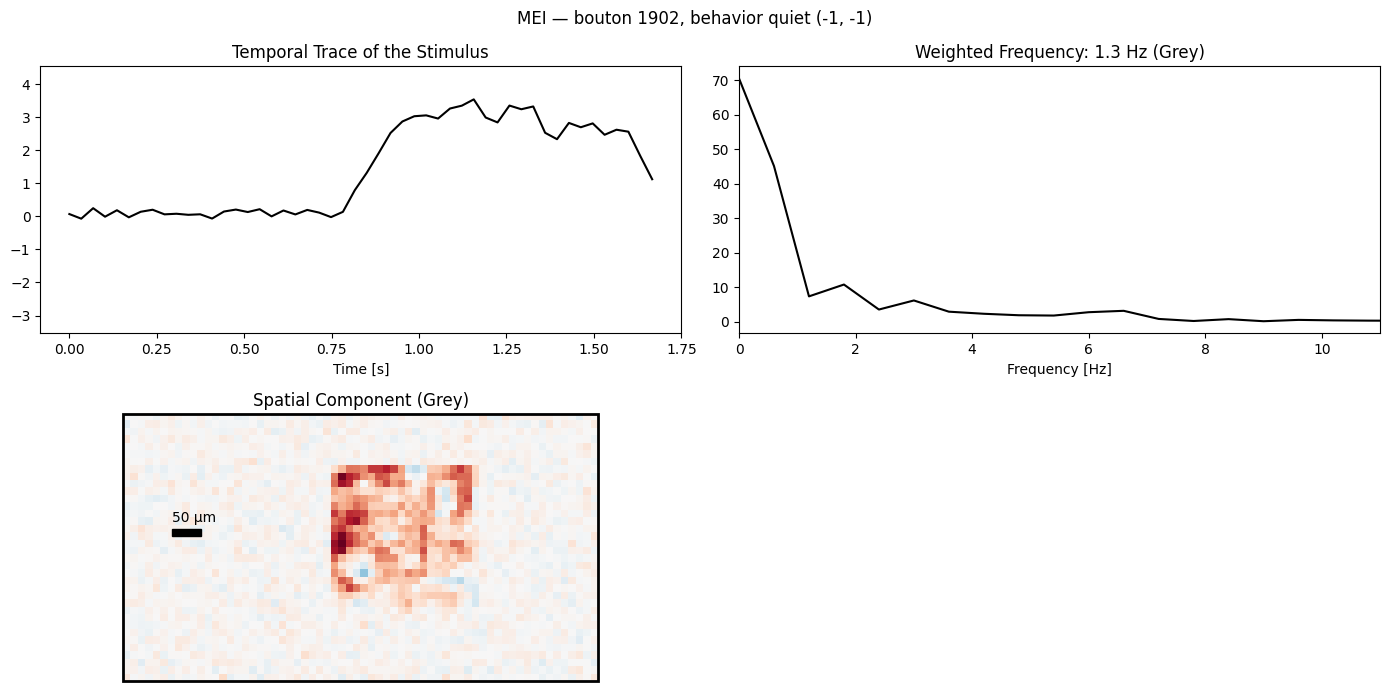

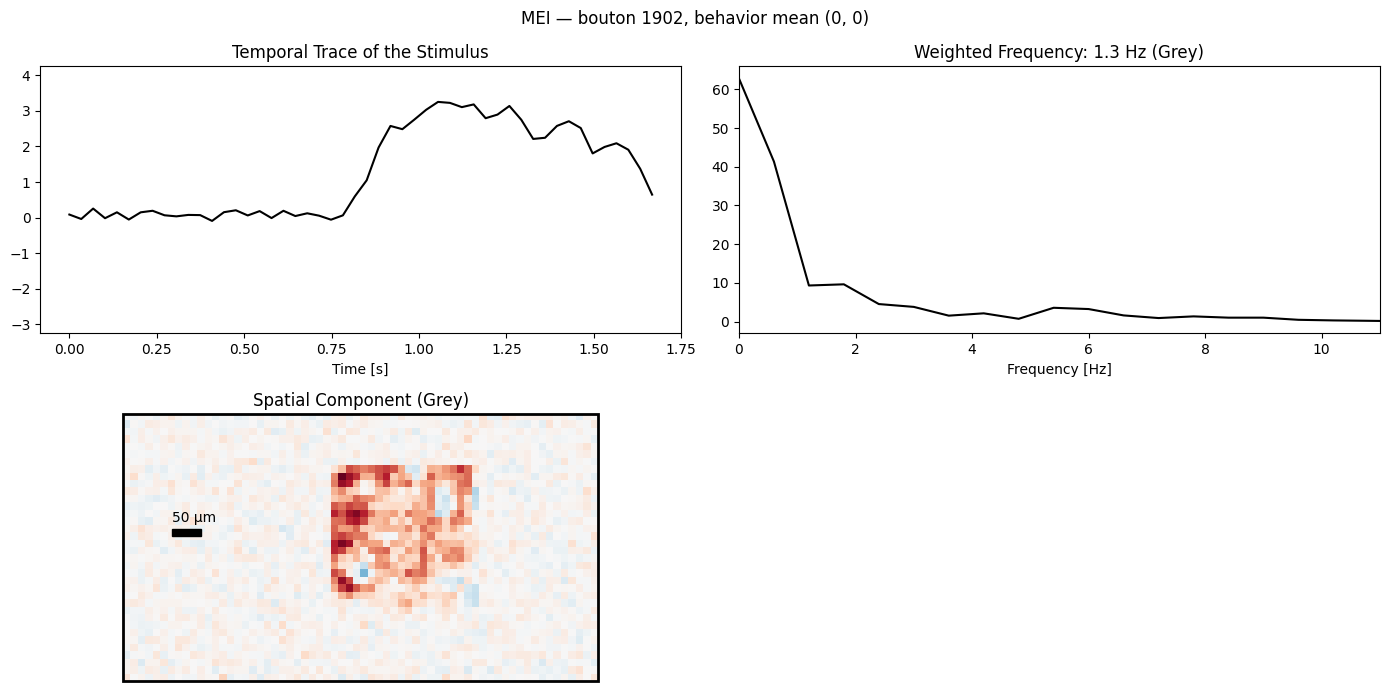

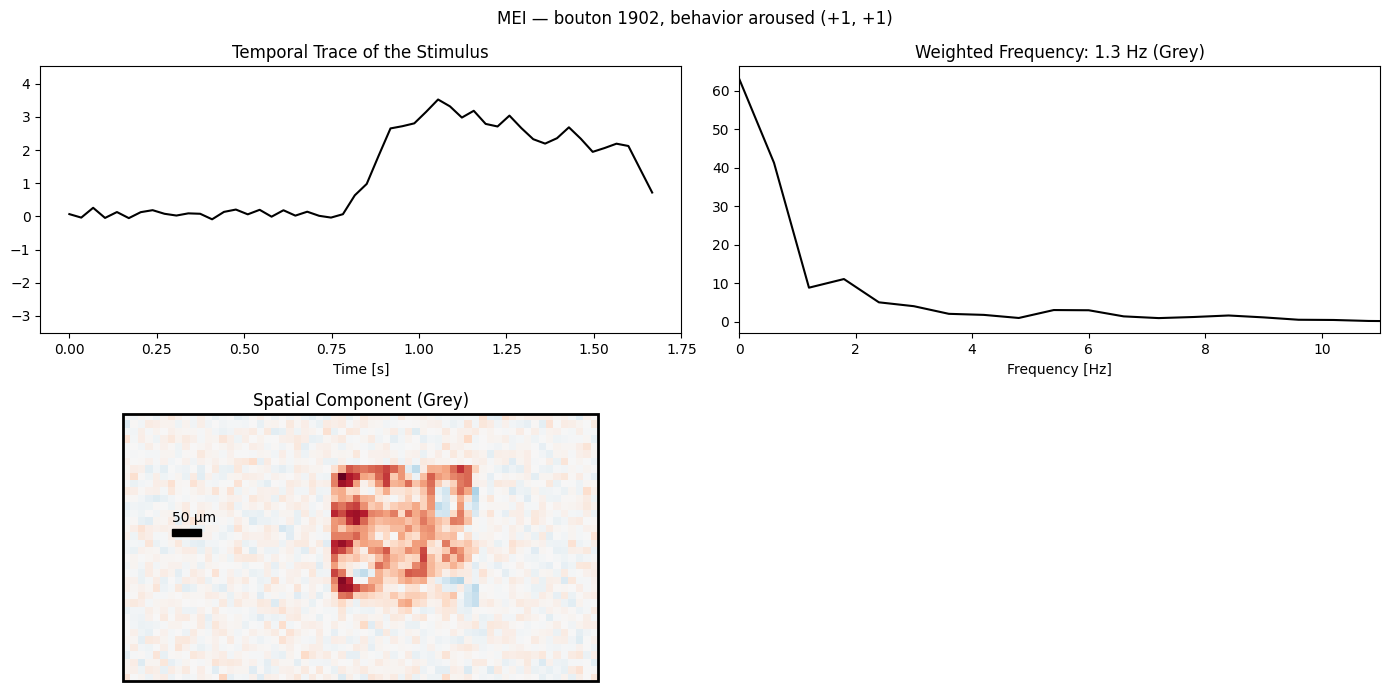

In [10]:
from openretina.utils.plotting import plot_stimulus_composition

# The optimized tensor is single-channel, so `plot_stimulus_composition` takes its greyscale path
# automatically. (Handing it 3 channels would run an SVD on the spatially-constant behavior
# channels, and at exactly 0.0 that divides by zero in video_analysis.py.)
bouton = top_boutons[0]
for state_name in BEHAVIOR_STATES:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    plot_stimulus_composition(
        stimulus=meis[(bouton, state_name)]["stimulus"][0],
        temporal_trace_ax=axes[0, 0],
        freq_ax=axes[0, 1],
        spatial_ax=axes[1, 0],
    )
    axes[1, 1].axis("off")
    fig.suptitle(f"MEI — bouton {bouton}, behavior {state_name}")
    plt.tight_layout()
    plt.show()

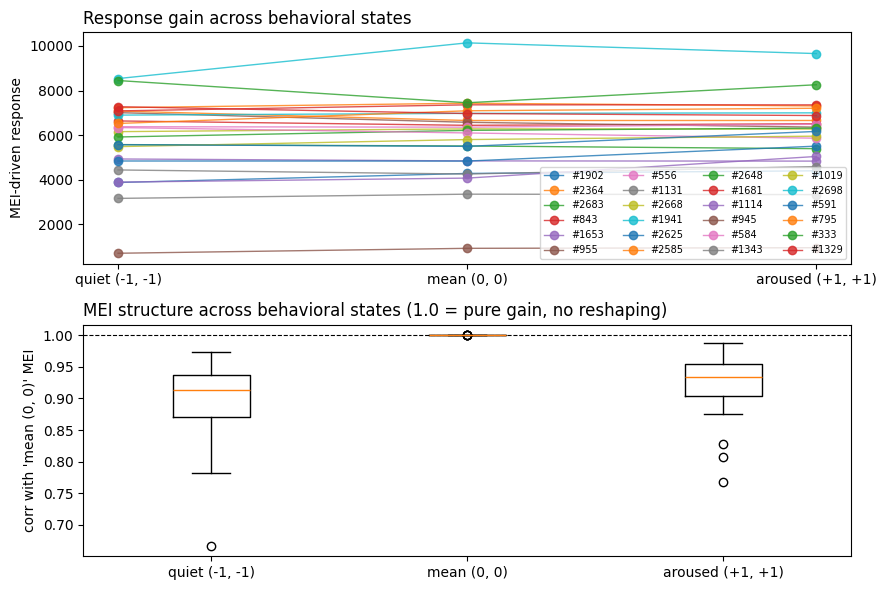

median similarity per state: {'quiet (-1, -1)': np.float64(0.914), 'mean (0, 0)': np.float64(1.0), 'aroused (+1, +1)': np.float64(0.934)}


In [11]:
# Does the behavior state rescale the MEI, or reshape it?
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
state_names = list(BEHAVIOR_STATES)

for bouton in top_boutons:
    responses = np.array([meis[(bouton, s)]["after"] for s in state_names])
    axes[0].plot(range(len(state_names)), responses, marker="o", lw=1, alpha=0.8, label=f"#{bouton}")

axes[0].set_xticks(range(len(state_names)), state_names)
axes[0].set_ylabel("MEI-driven response")
axes[0].set_title("Response gain across behavioral states", loc="left")
axes[0].legend(fontsize=7, ncol=4)

# Spatial correlation between each state's MEI and the mean-state MEI, per bouton.
reference_state = "mean (0, 0)"
similarity = np.array(
    [
        [
            float(
                torch.corrcoef(
                    torch.stack(
                        [
                            meis[(bouton, s)]["stimulus"].flatten(),
                            meis[(bouton, reference_state)]["stimulus"].flatten(),
                        ]
                    )
                )[0, 1]
            )
            for s in state_names
        ]
        for bouton in top_boutons
    ]
)
axes[1].boxplot([similarity[:, i] for i in range(len(state_names))], tick_labels=state_names)
axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set_ylabel(f"corr with '{reference_state}' MEI")
axes[1].set_title("MEI structure across behavioral states (1.0 = pure gain, no reshaping)", loc="left")
plt.tight_layout()
plt.show()

print("median similarity per state:", dict(zip(state_names, np.median(similarity, axis=0).round(3))))

## 2. Behavior-state modulation

`behavior_response_grid` holds one video fixed and sweeps the two behavior channels over a
17 × 17 grid spanning ±2 standard deviations, reducing each response over time.

Two probes, because the answer can depend on the stimulus: a bouton's own MEI (a strongly driving
input) and mid-grey (no drive at all, isolating the pure behavioral bias).

In [12]:
from openretina.insilico import MeanReducer, ResponseGrid, behavior_response_grid

reference_state = "mean (0, 0)"
probe_bouton = top_boutons[0]
mei_video = meis[(probe_bouton, reference_state)]["stimulus"][0, 0]        # (t, h, w)
grey_video = torch.zeros_like(mei_video)                                    # z-scored mid-grey

grids = {}
for probe_name, probe_video in [("MEI", mei_video), ("grey", grey_video)]:
    grids[probe_name] = behavior_response_grid(
        model,
        SESSION,
        probe_video,
        response_reducer=MeanReducer(axis=0),
        behavior_channels=BEHAVIOR_CHANNELS,
        pupil_center=PUPIL_CENTER,
        neuron_indices=top_boutons,
        device=device,
    )
    print(f"{probe_name:5s}: responses {grids[probe_name].responses.shape}")

for probe_name, grid in grids.items():
    print(f"  saved {grid.save(RESULTS_DIR / f'grid_sampled_{probe_name}').name}")

MEI  : responses (17, 17, 24)


grey : responses (17, 17, 24)
  saved grid_sampled_MEI.npz
  saved grid_sampled_grey.npz


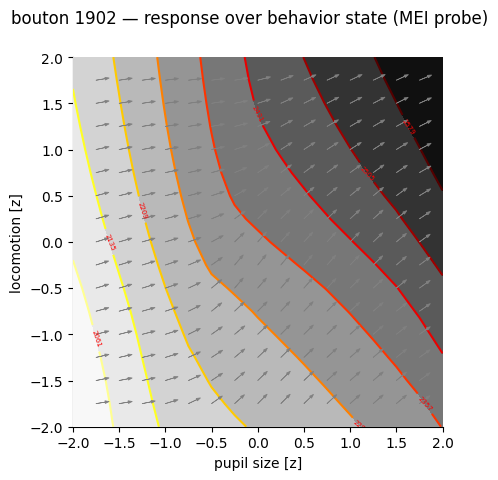

In [13]:
from openretina.utils.plotting import plot_vector_field_resp_iso

# `for_neuron` returns exactly the layout this plot expects. `tick_locations=None` matters: the
# default FixedLocator([-1, 0, 1]) is calibrated for the chromatic-contrast grid and would put all
# three ticks near the middle of a -2..+2 sweep.
grid = grids["MEI"]
neuron_slot = 0  # index into `top_boutons`
responses, gradients = grid.for_neuron(neuron_slot)

figure = plot_vector_field_resp_iso(
    grid.axis_values[0],
    grid.axis_values[1],
    gradients,
    responses,
    xlabel=grid.axis_names[0],
    ylabel=grid.axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"bouton {top_boutons[neuron_slot]} — response over behavior state (MEI probe)")
plt.show()

### The grid visits states the animal never produced

A rectangular sweep necessarily includes combinations like pupil `+2` with locomotion `−2`. The
empirical joint density says which parts of the grid are actually supported; read the corners with
that in mind.

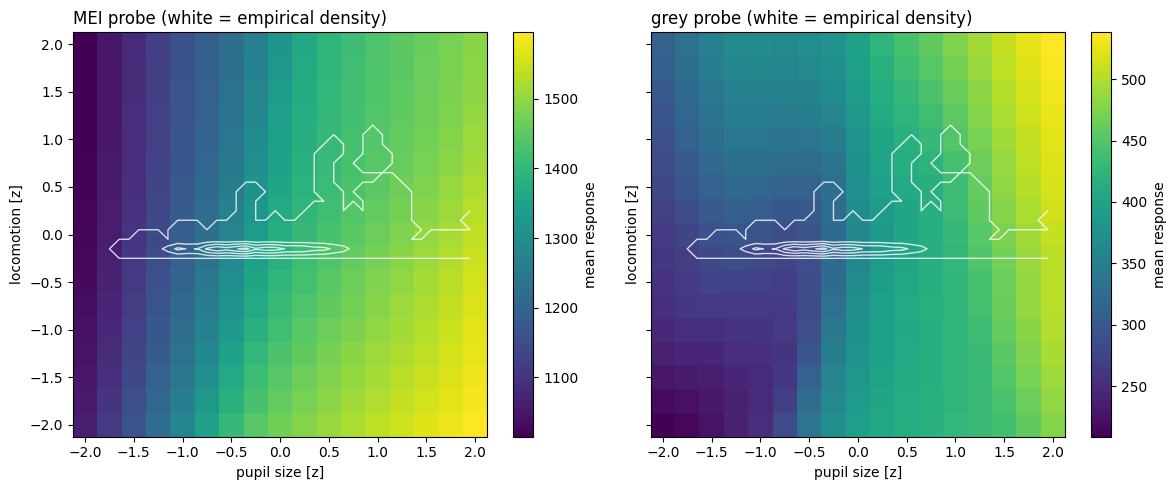

93.4% of recorded frames fall inside the swept +/-2 z range


In [14]:
# Empirical joint density of the two behavior channels. `behavior_trace` was captured further up,
# before the dataloader build released the movies.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
edges = np.linspace(-2, 2, 41)

for ax, (probe_name, grid) in zip(axes, grids.items()):
    mean_response = grid.responses.mean(axis=-1)  # averaged over the sampled boutons
    mesh = ax.pcolormesh(
        grid.axis_values[0], grid.axis_values[1], mean_response.T, shading="nearest", cmap="viridis"
    )
    ax.contour(
        *np.meshgrid(0.5 * (edges[:-1] + edges[1:]), 0.5 * (edges[:-1] + edges[1:]), indexing="ij"),
        np.histogram2d(behavior_trace[0], behavior_trace[1], bins=[edges, edges])[0],
        levels=4,
        colors="white",
        linewidths=1.0,
        alpha=0.8,
    )
    fig.colorbar(mesh, ax=ax, label="mean response")
    ax.set_xlabel(grid.axis_names[0])
    ax.set_ylabel(grid.axis_names[1])
    ax.set_title(f"{probe_name} probe (white = empirical density)", loc="left")

plt.tight_layout()
plt.show()

in_range = ((np.abs(behavior_trace) <= 2).all(axis=0)).mean()
print(f"{in_range:.1%} of recorded frames fall inside the swept +/-2 z range")

MEI  : 2710/2710 finite | median 0.274
grey : 2710/2710 finite | median 0.280


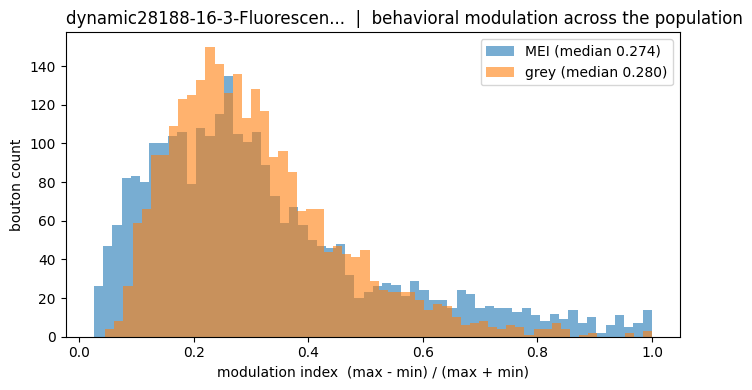

  saved grid_population_MEI.npz


  saved grid_population_grey.npz


In [15]:
# Population modulation index over ALL boutons of this session, on both probes.
population_grids = {
    probe_name: behavior_response_grid(
        model,
        SESSION,
        probe_video,
        response_reducer=MeanReducer(axis=0),
        behavior_channels=BEHAVIOR_CHANNELS,
        pupil_center=PUPIL_CENTER,
        compute_gradients=False,   # not needed for the index, and it doubles the memory
        device=device,
    )
    for probe_name, probe_video in [("MEI", mei_video), ("grey", grey_video)]
}

plt.figure(figsize=(7, 4))
for probe_name, grid in population_grids.items():
    index = grid.modulation_index()
    finite = index[np.isfinite(index)]
    plt.hist(finite, bins=60, alpha=0.6, label=f"{probe_name} (median {np.median(finite):.3f})")
    print(f"{probe_name:5s}: {len(finite)}/{len(index)} finite | median {np.median(finite):.3f}")

plt.xlabel("modulation index  (max - min) / (max + min)")
plt.ylabel("bouton count")
plt.title(f"{SESSION[:28]}...  |  behavioral modulation across the population", loc="left")
plt.legend()
plt.tight_layout()
plt.show()

for probe_name, grid in population_grids.items():
    print(f"  saved {grid.save(RESULTS_DIR / f'grid_population_{probe_name}').name}")

## 3. The pupil shifter: how far does it move a receptive field?

`shifter_shift_grid` evaluates the shifter MLPs directly — no core, no readout, milliseconds for all
10 sessions. That answers the displacement question without the confound of a response.

The shift is in normalized grid units; `shift_to_core_pixels` converts to core-output pixels. Note
the last-axis order is `(width, height)`, because `grid_sample` reads `grid[..., 0]` as x.

In [16]:
from openretina.insilico import shift_to_core_pixels, shifter_shift_grid

shifts = shifter_shift_grid(model, device=device)

# The core's output spatial shape sets the pixel conversion.
with torch.no_grad():
    probe = torch.zeros(model.stimulus_shape(MEI_TIME_STEPS), device=device)
    core_output_shape = tuple(model.core(probe).shape[-2:])
print("core output (h, w):", core_output_shape)

rows = []
for session, shift in shifts.items():
    pixels = shift_to_core_pixels(shift, core_output_shape, align_corners=model.readout[session].align_corners)
    displacement = np.linalg.norm(pixels, axis=-1)
    rows.append((session, displacement.max(), np.abs(pixels[..., 0]).max(), np.abs(pixels[..., 1]).max()))

print(f"\n{'session':<44}{'max |shift|':>12}{'max dx':>9}{'max dy':>9}   (core pixels)")
for session, total, dx, dy in rows:
    print(f"{session[:42]:<44}{total:>12.2f}{dx:>9.2f}{dy:>9.2f}")

save_arrays(
    "shifter",
    sessions=np.asarray(list(shifts)),
    shifts=np.stack([shifts[s] for s in shifts]),
    align_corners=np.asarray([model.readout[s].align_corners for s in shifts]),
    core_output_shape=np.asarray(core_output_shape),
    pupil_values=np.linspace(*BEHAVIOR_SWEEP_RANGE, next(iter(shifts.values())).shape[0]),
)

core output (h, w): (18, 46)

session                                      max |shift|   max dx   max dy   (core pixels)
dynamic28188-16-3-Fluorescence-7b721b-v4a           2.99     2.91     1.44
dynamic28188-16-5-Fluorescence-7b721b-v4a           3.05     3.04     1.34
dynamic28188-17-2-Fluorescence-7b721b-v4a           4.53     3.98     3.25
dynamic28188-18-4-Fluorescence-7b721b-v4a           5.10     2.62     4.44
dynamic28188-19-9-Fluorescence-7b721b-v4a           2.46     2.45     1.77
dynamic28712-3-8-Fluorescence-7b721b-v4a            7.55     5.38     6.52
dynamic29163-2-7-Fluorescence-7b721b-v4a            5.23     4.98     1.59
dynamic29163-4-4-Fluorescence-7b721b-v4a            3.25     3.22     0.44
dynamic29163-5-8-Fluorescence-7b721b-v4a            2.29     2.26     0.35
dynamic29163-6-5-Fluorescence-7b721b-v4a            2.53     2.11     2.10
  saved shifter.npz                   0.02 MB


PosixPath('/mnt/lustre/work/bethge/bkr578/projects/open-retina/openretina_assets/insilico/qiu_2026/dynamic28188-16-3-Fluorescence-7b721b-v4a/shifter.npz')

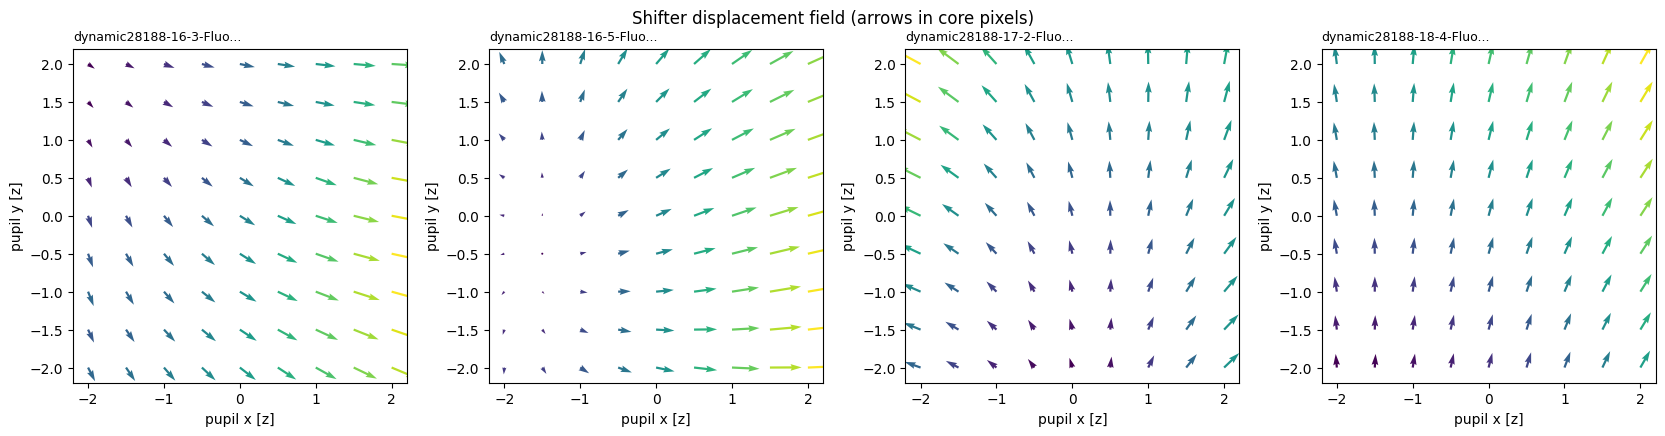

In [17]:
# Quiver of the shift field for a few sessions.
n_show = min(4, len(shifts))
fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 4.2), squeeze=False)
step = 2  # thin the 17x17 grid so the arrows stay readable

for ax, (session, shift) in zip(axes[0], list(shifts.items())[:n_show]):
    pixels = shift_to_core_pixels(shift, core_output_shape, align_corners=model.readout[session].align_corners)
    values = np.linspace(*BEHAVIOR_SWEEP_RANGE, shift.shape[0])
    mesh_x, mesh_y = np.meshgrid(values, values, indexing="ij")
    ax.quiver(
        mesh_x[::step, ::step], mesh_y[::step, ::step],
        pixels[::step, ::step, 0], pixels[::step, ::step, 1],
        np.linalg.norm(pixels[::step, ::step], axis=-1),
        cmap="viridis", angles="xy",
    )
    ax.set_xlabel("pupil x [z]")
    ax.set_ylabel("pupil y [z]")
    ax.set_title(session[:22] + "...", fontsize=9, loc="left")
    ax.set_aspect("equal")

fig.suptitle("Shifter displacement field (arrows in core pixels)")
plt.tight_layout()
plt.show()

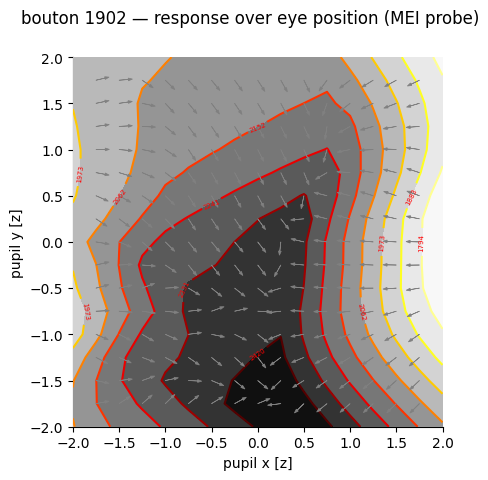

eye-position modulation index for the sampled boutons: [0.191 0.062 0.106 0.217 0.018 0.234 0.225 0.147 0.07  0.105 0.126 0.2
 0.043 0.24  0.097 0.377 0.091 0.032 0.163 0.287 0.199 0.181 0.18  0.256]
  saved grid_pupil_center.npz


In [18]:
# What does that displacement cost in response terms?
from openretina.insilico import pupil_center_response_grid

# The full model input this time -- behavior channels included, since they are held fixed here.
full_stimulus = torch.zeros(model.stimulus_shape(MEI_TIME_STEPS)[1:])
full_stimulus[0] = mei_video
full_stimulus[BEHAVIOR_CHANNELS[0]] = 0.0
full_stimulus[BEHAVIOR_CHANNELS[1]] = 0.0

pupil_grid = pupil_center_response_grid(
    model,
    SESSION,
    full_stimulus,
    response_reducer=MeanReducer(axis=0),
    neuron_indices=top_boutons,
    device=device,
)

responses, gradients = pupil_grid.for_neuron(0)
figure = plot_vector_field_resp_iso(
    pupil_grid.axis_values[0],
    pupil_grid.axis_values[1],
    gradients,
    responses,
    xlabel=pupil_grid.axis_names[0],
    ylabel=pupil_grid.axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"bouton {top_boutons[0]} — response over eye position (MEI probe)")
plt.show()

index = pupil_grid.modulation_index()
print("eye-position modulation index for the sampled boutons:", np.round(index, 3))

print(f"  saved {pupil_grid.save(RESULTS_DIR / 'grid_pupil_center').name}")

**Reading the eye-position sweep.** The shift is added *after* `mu` is clamped to `[-1, 1]`, so a
large enough shift pushes a bouton off the feature map and its response collapses. A plateau at the
edge of this grid is a property of the readout, not a tuning curve.

## Summary

- MEI amplitude changes with behavioral state while MEI structure stays nearly fixed — the gain-only
  prediction the architecture makes, now measured rather than assumed.
- The population modulation index quantifies how much of that gain there is, and the empirical
  density overlay marks which parts of the sweep the animal actually visited.
- The shifter's displacement, in core pixels, says whether eye-movement compensation is a
  few-pixel correction or something larger.

## 4. Reloading these results without re-running anything

Everything above is on disk. The cell below reloads it *from the files alone* -- no model, no GPU,
no dataset -- and re-plots two figures, so the roundtrip is verified rather than asserted.

Copy this cell into a fresh notebook to explore the results interactively. The only thing you need
to set is `SESSION`.

```
openretina_assets/insilico/qiu_2026/<session>/
  metadata.json            run parameters: checkpoint, behavior states, MEI settings, constants
  boutons.npz              val_corr (all boutons), top_boutons (the ones with MEIs)
  meis.npz                 stimuli (n_boutons, n_states, T, H, W) + before/after/lr per MEI
  grid_sampled_{MEI,grey}.npz      behavior sweep, sampled boutons, with gradients
  grid_population_{MEI,grey}.npz   behavior sweep, all boutons, no gradients
  grid_pupil_center.npz    eye-position sweep
  shifter.npz              per-session shift fields, align_corners, core output shape
  behavior_trace.npz       recorded behavior, for the empirical-density overlay
```

In [19]:
# --- Reload from disk only. Everything below is prefixed `re_` so it cannot silently reuse
# --- a variable that is still in this kernel's memory.
import json
from pathlib import Path

import numpy as np
from openretina.insilico import ResponseGrid, shift_to_core_pixels

re_dir = RESULTS_DIR  # in a fresh kernel: Path("openretina_assets/insilico/qiu_2026") / SESSION

re_meta = json.loads((re_dir / "metadata.json").read_text())
re_meis = np.load(re_dir / "meis.npz")
re_boutons = np.load(re_dir / "boutons.npz")
re_shifter = np.load(re_dir / "shifter.npz")
re_grids = {n: ResponseGrid.load(re_dir / f"grid_sampled_{n}.npz") for n in ("MEI", "grey")}
re_population = {n: ResponseGrid.load(re_dir / f"grid_population_{n}.npz") for n in ("MEI", "grey")}
re_pupil = ResponseGrid.load(re_dir / "grid_pupil_center.npz")

re_states = [str(s) for s in re_meis["state_names"]]
print("checkpoint :", Path(re_meta["checkpoint"]).name)
print("session    :", re_meta["session"])
print("MEIs       :", re_meis["stimuli"].shape, "(boutons, states, T, H, W)  states:", re_states)
print("boutons    :", re_boutons["val_corr"].shape[0], "scored,", re_boutons["top_boutons"].shape[0], "with MEIs")
print("grids      :", {k: v.responses.shape for k, v in re_grids.items()})
print("population :", {k: v.responses.shape for k, v in re_population.items()})
print("shifter    :", re_shifter["shifts"].shape, "for", len(re_shifter["sessions"]), "sessions")

# The reloaded arrays must equal what is still in memory -- this is the actual roundtrip check.
assert np.array_equal(re_boutons["top_boutons"], np.asarray(top_boutons))
np.testing.assert_array_equal(re_grids["MEI"].responses, grids["MEI"].responses)
np.testing.assert_allclose(
    re_meis["stimuli"][0, 0], meis[(top_boutons[0], re_states[0])]["stimulus"].numpy()[0, 0], rtol=0, atol=0
)
print("\nroundtrip verified: reloaded arrays are identical to the in-memory ones")

checkpoint : epoch=49_val_evaluation_loss=0.401_final.ckpt
session    : dynamic28188-16-3-Fluorescence-7b721b-v4a


MEIs       : (24, 3, 50, 36, 64) (boutons, states, T, H, W)  states: ['quiet (-1, -1)', 'mean (0, 0)', 'aroused (+1, +1)']
boutons    : 2710 scored, 24 with MEIs
grids      : {'MEI': (17, 17, 24), 'grey': (17, 17, 24)}
population : {'MEI': (17, 17, 2710), 'grey': (17, 17, 2710)}
shifter    : (10, 17, 17, 2) for 10 sessions



roundtrip verified: reloaded arrays are identical to the in-memory ones


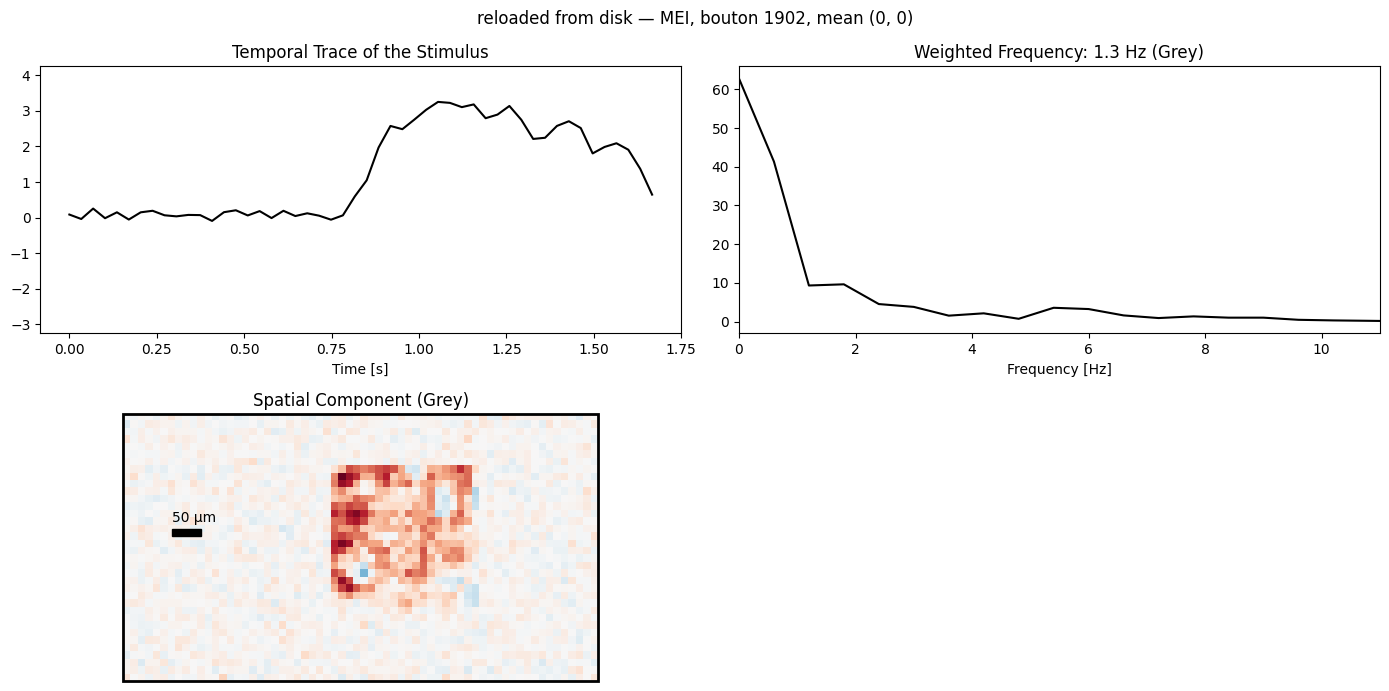

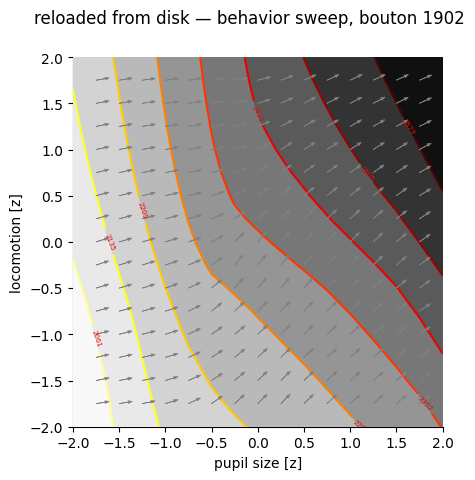

dynamic28188-16-3-Fluorescence-7b7: max displacement 2.99 px


In [20]:
# Re-plot straight from the reloaded arrays, using no model and no GPU.
from openretina.utils.plotting import plot_stimulus_composition, plot_vector_field_resp_iso

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
plot_stimulus_composition(
    stimulus=torch.from_numpy(re_meis["stimuli"][0, 1])[None],  # (1, T, H, W): bouton 0, mean state
    temporal_trace_ax=axes[0, 0],
    freq_ax=axes[0, 1],
    spatial_ax=axes[1, 0],
)
axes[1, 1].axis("off")
fig.suptitle(f"reloaded from disk — MEI, bouton {re_meis['bouton_ids'][0]}, {re_states[1]}")
plt.tight_layout()
plt.show()

re_responses, re_gradients = re_grids["MEI"].for_neuron(0)
figure = plot_vector_field_resp_iso(
    re_grids["MEI"].axis_values[0],
    re_grids["MEI"].axis_values[1],
    re_gradients,
    re_responses,
    xlabel=re_grids["MEI"].axis_names[0],
    ylabel=re_grids["MEI"].axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"reloaded from disk — behavior sweep, bouton {re_meis['bouton_ids'][0]}")
plt.show()

# Shifter displacement, recomputed in pixels from the saved normalized shifts.
re_pixels = shift_to_core_pixels(
    re_shifter["shifts"][0], re_shifter["core_output_shape"], align_corners=bool(re_shifter["align_corners"][0])
)
print(f"{str(re_shifter['sessions'][0])[:34]}: max displacement {np.linalg.norm(re_pixels, axis=-1).max():.2f} px")